#  Analyzing The Dataset 

In [2]:
# For a DataFrame
import pandas as pd

In [3]:
df = pd.read_csv("crop_yield_dataset.csv")

In [4]:
df.head()

,Temperature (°C),Rainfall (mm),Humidity (%),Soil Type,Weather Condition,Crop Type,Yield (tons/hectare)
0,22.490802,185.132929,53.085284,Sandy,Sunny,Barley,2.818937
1,34.014286,541.900947,52.348940,Loamy,Sunny,Corn,8.014166
2,29.639879,872.945836,85.312729,Peaty,Rainy,Wheat,9.249868
3,26.973170,732.224886,52.477310,Sandy,Sunny,Soybeans,7.947481
4,18.120373,806.561148,53.597486,Clay,Stormy,Barley,6.262616


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature (°C)      1000 non-null   float64
 1   Rainfall (mm)         1000 non-null   float64
 2   Humidity (%)          1000 non-null   float64
 3   Soil Type             1000 non-null   object 
 4   Weather Condition     1000 non-null   object 
 5   Crop Type             1000 non-null   object 
 6   Yield (tons/hectare)  1000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


In [6]:
df.describe()

,Temperature (°C),Rainfall (mm),Humidity (%),Yield (tons/hectare)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.805131,507.017305,65.120286,5.901829
std,5.842747,292.189893,14.533710,2.354828
min,15.092640,3.218264,40.000582,2.005020
25%,19.719465,241.074271,53.067549,3.842958
50%,24.936148,518.733906,65.030696,5.868498
75%,29.886392,760.465057,77.955176,7.929261
max,34.994353,999.413726,89.891043,9.992396


In [7]:
df = df.rename(columns = {
    "Temperature (°C)":'temperature',
    "Rainfall (mm)":'rainfall',
    "Humidity (%)":"humidity",
    "Soil Type":"soil_type",
    "Weather Condition":"weather_condition",
    'Crop Type':"crop_type",
    'Yield (tons/hectare)':"yield"
})

In [8]:
#Useful for categorical columns
df['soil_type'].value_counts()

soil_type
Sandy    208
Loamy    204
Peaty    203
Clay     197
Silty    188
Name: count, dtype: int64

In [9]:
df["weather_condition"].value_counts()

weather_condition
Rainy     258
Stormy    258
Cloudy    256
Sunny     228
Name: count, dtype: int64

In [10]:
df["crop_type"].value_counts()

crop_type
Rice        228
Wheat       203
Soybeans    199
Corn        189
Barley      181
Name: count, dtype: int64

In [11]:
print(len(df),len(df.columns))
df_clean = df.dropna(axis=0)
df_clean = df_clean.dropna(axis=1)
print(len(df_clean),len(df_clean.columns))


1000 7
1000 7


### Let's Visualize the data 

In [13]:
import matplotlib.pyplot as plt

In [14]:
print(df["soil_type"].unique())

['Sandy' 'Loamy' 'Peaty' 'Clay' 'Silty']


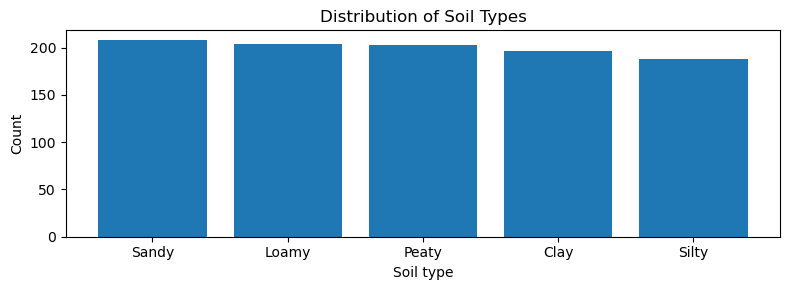

In [15]:
soil_counts = df["soil_type"].value_counts()
plt.figure(figsize=(8,3))
plt.bar(soil_counts.index,soil_counts.values)
plt.title("Distribution of Soil Types")
plt.xlabel("Soil type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
print(df["crop_type"].unique())

['Barley' 'Corn' 'Wheat' 'Soybeans' 'Rice']


# Creating a Test Set

In [18]:
X = df.drop("yield",axis=1)
y = df["yield"]

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
print(X_train)

     temperature    rainfall   humidity soil_type weather_condition crop_type
29     15.929008  828.915474  72.708730     Peaty             Sunny     Wheat
535    33.895315  121.886093  81.707230     Peaty             Rainy      Rice
695    27.212401   68.172309  65.951614      Clay            Stormy     Wheat
557    15.575654  411.028470  54.978284     Sandy            Stormy     Wheat
836    33.296918  128.095746  89.662751     Loamy            Cloudy      Corn
..           ...         ...        ...       ...               ...       ...
106    23.207658  396.242019  82.858963     Sandy             Rainy      Corn
270    31.187223  694.981886  45.211240      Clay            Stormy      Corn
860    30.510552  776.447446  83.338518      Clay            Cloudy    Barley
435    29.019383   29.973590  59.474095      Clay             Sunny    Barley
102    21.287120  883.785885  47.897741     Loamy             Rainy      Corn

[800 rows x 6 columns]


In [21]:
print(X_test)

     temperature    rainfall   humidity soil_type weather_condition crop_type
521    22.617817  934.436027  46.721756     Sandy             Sunny  Soybeans
737    31.331989  194.622512  67.224117      Clay             Rainy  Soybeans
740    24.253596  827.537896  58.284037     Sandy            Cloudy    Barley
660    22.121935  600.594333  63.614090     Peaty             Rainy      Rice
411    34.001239  111.919619  47.027648     Loamy             Rainy  Soybeans
..           ...         ...        ...       ...               ...       ...
408    33.107640  585.354364  89.401798     Silty            Cloudy      Corn
332    15.287870  228.454741  70.189773     Loamy            Cloudy  Soybeans
208    15.101232  273.626666  54.610912     Peaty             Rainy  Soybeans
613    16.635181  324.333753  77.045203     Silty            Cloudy      Rice
78     22.169315  218.253888  89.249483     Silty             Rainy  Soybeans

[200 rows x 6 columns]


In [22]:
print(y_train)

29     7.566360
535    2.566331
695    8.022780
557    3.664848
836    7.513451
         ...   
106    3.048469
270    2.995375
860    9.626531
435    9.985599
102    4.258511
Name: yield, Length: 800, dtype: float64


In [23]:
print(y_test)

521    9.144910
737    9.858048
740    4.813761
660    5.309648
411    5.485377
         ...   
408    7.335483
332    7.732850
208    8.353459
613    4.733991
78     8.804034
Name: yield, Length: 200, dtype: float64


## One-Hot Encoder

In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
# ohe = OneHotEncoder()

# X_train_1hot = ohe.fit_transform(X_train)

# X_train_1hot

In [27]:
X_train_1hot = pd.get_dummies(X_train,columns = ["soil_type","weather_condition","crop_type"],drop_first=True)
X_test_1hot = pd.get_dummies(X_test,columns = ["soil_type","weather_condition","crop_type"],drop_first=True)


In [28]:
print(len(X_train_1hot.columns))

14


In [29]:
X_train_1hot

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat
29,15.929008,828.915474,72.708730,False,True,False,False,False,False,True,False,False,False,True
535,33.895315,121.886093,81.707230,False,True,False,False,True,False,False,False,True,False,False
695,27.212401,68.172309,65.951614,False,False,False,False,False,True,False,False,False,False,True
557,15.575654,411.028470,54.978284,False,False,True,False,False,True,False,False,False,False,True
836,33.296918,128.095746,89.662751,True,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,23.207658,396.242019,82.858963,False,False,True,False,True,False,False,True,False,False,False
270,31.187223,694.981886,45.211240,False,False,False,False,False,True,False,True,False,False,False
860,30.510552,776.447446,83.338518,False,False,False,False,False,False,False,False,False,False,False
435,29.019383,29.973590,59.474095,False,False,False,False,False,False,True,False,False,False,False


In [30]:
X_train_1hot["split"] = "train"

In [31]:
X_train_1hot

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split
29,15.929008,828.915474,72.708730,False,True,False,False,False,False,True,False,False,False,True,train
535,33.895315,121.886093,81.707230,False,True,False,False,True,False,False,False,True,False,False,train
695,27.212401,68.172309,65.951614,False,False,False,False,False,True,False,False,False,False,True,train
557,15.575654,411.028470,54.978284,False,False,True,False,False,True,False,False,False,False,True,train
836,33.296918,128.095746,89.662751,True,False,False,False,False,False,False,True,False,False,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,23.207658,396.242019,82.858963,False,False,True,False,True,False,False,True,False,False,False,train
270,31.187223,694.981886,45.211240,False,False,False,False,False,True,False,True,False,False,False,train
860,30.510552,776.447446,83.338518,False,False,False,False,False,False,False,False,False,False,False,train
435,29.019383,29.973590,59.474095,False,False,False,False,False,False,True,False,False,False,False,train


In [32]:
X_test_1hot

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat
521,22.617817,934.436027,46.721756,False,False,True,False,False,False,True,False,False,True,False
737,31.331989,194.622512,67.224117,False,False,False,False,True,False,False,False,False,True,False
740,24.253596,827.537896,58.284037,False,False,True,False,False,False,False,False,False,False,False
660,22.121935,600.594333,63.614090,False,True,False,False,True,False,False,False,True,False,False
411,34.001239,111.919619,47.027648,True,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,33.107640,585.354364,89.401798,False,False,False,True,False,False,False,True,False,False,False
332,15.287870,228.454741,70.189773,True,False,False,False,False,False,False,False,False,True,False
208,15.101232,273.626666,54.610912,False,True,False,False,True,False,False,False,False,True,False
613,16.635181,324.333753,77.045203,False,False,False,True,False,False,False,False,True,False,False


In [33]:
X_test_1hot["split"] = "test"

In [34]:
X_test_1hot

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split
521,22.617817,934.436027,46.721756,False,False,True,False,False,False,True,False,False,True,False,test
737,31.331989,194.622512,67.224117,False,False,False,False,True,False,False,False,False,True,False,test
740,24.253596,827.537896,58.284037,False,False,True,False,False,False,False,False,False,False,False,test
660,22.121935,600.594333,63.614090,False,True,False,False,True,False,False,False,True,False,False,test
411,34.001239,111.919619,47.027648,True,False,False,False,True,False,False,False,False,True,False,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,33.107640,585.354364,89.401798,False,False,False,True,False,False,False,True,False,False,False,test
332,15.287870,228.454741,70.189773,True,False,False,False,False,False,False,False,False,True,False,test
208,15.101232,273.626666,54.610912,False,True,False,False,True,False,False,False,False,True,False,test
613,16.635181,324.333753,77.045203,False,False,False,True,False,False,False,False,True,False,False,test


In [35]:
final_1hot = pd.concat([X_train_1hot,X_test_1hot],axis=0)

In [36]:
final_1hot

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split
29,15.929008,828.915474,72.708730,False,True,False,False,False,False,True,False,False,False,True,train
535,33.895315,121.886093,81.707230,False,True,False,False,True,False,False,False,True,False,False,train
695,27.212401,68.172309,65.951614,False,False,False,False,False,True,False,False,False,False,True,train
557,15.575654,411.028470,54.978284,False,False,True,False,False,True,False,False,False,False,True,train
836,33.296918,128.095746,89.662751,True,False,False,False,False,False,False,True,False,False,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,33.107640,585.354364,89.401798,False,False,False,True,False,False,False,True,False,False,False,test
332,15.287870,228.454741,70.189773,True,False,False,False,False,False,False,False,False,True,False,test
208,15.101232,273.626666,54.610912,False,True,False,False,True,False,False,False,False,True,False,test
613,16.635181,324.333753,77.045203,False,False,False,True,False,False,False,False,True,False,False,test


In [37]:
final_1hot.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_1hot.csv",index=False)

## LeaveOneOutEncoder

In [39]:
from category_encoders.leave_one_out import LeaveOneOutEncoder

In [40]:
loo_encoder = LeaveOneOutEncoder(cols=['soil_type',"weather_condition","crop_type"])

X_train_loo_encoder = loo_encoder.fit_transform(X_train,y_train)
X_test_loo_encoder = loo_encoder.transform(X_test)


In [41]:
X_train_loo_encoder

,temperature,rainfall,humidity,soil_type,weather_condition,crop_type
29,15.929008,828.915474,72.708730,5.947070,5.800713,6.145453
535,33.895315,121.886093,81.707230,5.977010,5.792711,5.936277
695,27.212401,68.172309,65.951614,5.646986,5.902408,6.142703
557,15.575654,411.028470,54.978284,6.020760,5.923666,6.168956
836,33.296918,128.095746,89.662751,5.980224,6.093390,5.620369
...,...,...,...,...,...,...
106,23.207658,396.242019,82.858963,6.024408,5.790415,5.650135
270,31.187223,694.981886,45.211240,5.680502,5.926932,5.650489
860,30.510552,776.447446,83.338518,5.636295,6.082929,5.869557
435,29.019383,29.973590,59.474095,5.633901,5.787198,5.867046


In [42]:
print(len(X_train_loo_encoder.columns))

6


In [43]:
X_train_loo_encoder["split"] = "train"

In [44]:
X_test_loo_encoder['split'] = "test"

In [45]:
final_loo_encoder = pd.concat([X_train_loo_encoder,X_test_loo_encoder],axis=0)

In [46]:
final_loo_encoder

,temperature,rainfall,humidity,soil_type,weather_condition,crop_type,split
29,15.929008,828.915474,72.708730,5.947070,5.800713,6.145453,train
535,33.895315,121.886093,81.707230,5.977010,5.792711,5.936277,train
695,27.212401,68.172309,65.951614,5.646986,5.902408,6.142703,train
557,15.575654,411.028470,54.978284,6.020760,5.923666,6.168956,train
836,33.296918,128.095746,89.662751,5.980224,6.093390,5.620369,train
...,...,...,...,...,...,...,...
408,33.107640,585.354364,89.401798,5.868918,6.100385,5.632905,test
332,15.287870,228.454741,70.189773,5.989928,6.100385,5.880593,test
208,15.101232,273.626666,54.610912,5.956709,5.777420,5.880593,test
613,16.635181,324.333753,77.045203,5.868918,6.100385,5.917129,test


In [47]:
final_loo_encoder.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_loo_encoder.csv",index=False)

## Import Pickle

In [49]:
import pickle

In [50]:
with open("loo_encoder.pkl","wb") as f:
    pickle.dump(loo_encoder,f)

In [51]:
with open("loo_encoder.pkl","rb") as f:
    loaded_encoder = pickle.load(f)

## Standard Scaler


In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler_std = StandardScaler()

### Standard Scaler with 1HotEncoding

In [56]:
X_train_1hot_scaled = scaler_std.fit_transform(X_train_1hot[['temperature', 'rainfall', 'humidity']])
X_test_1hot_scaled = scaler_std.transform(X_test_1hot[['temperature', 'rainfall', 'humidity']])

In [57]:
X_train_1hot_scaled

array([[-1.5340594 ,  1.07782942,  0.50747353],
       [ 1.536054  , -1.3453489 ,  1.12953535],
       [ 0.39406618, -1.52944037,  0.04035744],
       ...,
       [ 0.95765999,  0.89800749,  1.24230548],
       [ 0.70284634, -1.66035757, -0.40743025],
       [-0.61845609,  1.26588496, -1.20769784]])

In [58]:
X_train_1hot_scaled_df = pd.DataFrame(X_train_1hot_scaled, columns=['temperature','rainfall','humidity']) 
X_test_1hot_scaled_df = pd.DataFrame(X_test_1hot_scaled, columns=['temperature','rainfall','humidity']) 

In [59]:
X_train_1hot_scaled_df["split"] = "train"
X_test_1hot_scaled_df["split"]  = "test"

In [60]:
final_1hot_scaled = pd.concat([X_train_1hot_scaled_df,X_test_1hot_scaled_df])

In [61]:
final_1hot_scaled.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_1hot_scaled.csv",index=False)

### Standard Scaler with LeaveOneOutEncoder

In [63]:
X_train_looe_scaled = scaler_std.fit_transform(X_train_loo_encoder[['temperature', 'rainfall', 'humidity']])
X_test_looe_scaled = scaler_std.fit_transform(X_test_loo_encoder[['temperature', 'rainfall', 'humidity']])

In [64]:
X_train_looe_scaled

array([[-1.5340594 ,  1.07782942,  0.50747353],
       [ 1.536054  , -1.3453489 ,  1.12953535],
       [ 0.39406618, -1.52944037,  0.04035744],
       ...,
       [ 0.95765999,  0.89800749,  1.24230548],
       [ 0.70284634, -1.66035757, -0.40743025],
       [-0.61845609,  1.26588496, -1.20769784]])

In [65]:
X_train_looe_scaled_df = pd.DataFrame(X_train_looe_scaled,columns = ['temperature','rainfall','humidity']) 
X_test_looe_scaled_df = pd.DataFrame(X_test_looe_scaled,columns = ['temperature','rainfall','humidity'])

In [66]:
X_train_looe_scaled_df["split"] = "train"
X_test_looe_scaled_df["split"] = "test"

In [67]:
final_looe_scaled = pd.concat([X_train_looe_scaled_df,X_test_looe_scaled_df])

In [68]:
final_looe_scaled.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_looe_scaled.csv",index=False)

## Min-Max-Scaler

In [70]:
from sklearn.preprocessing import MinMaxScaler

In [71]:
scaler_mm = MinMaxScaler()

### Min-Max_Scaler with 1HotEncoding

In [73]:
X_train_1hot_scaled_mm = scaler_mm.fit_transform(X_train_1hot[['temperature', 'rainfall', 'humidity']])
X_test_1hot_scaled_mm = scaler_mm.transform(X_test_1hot[['temperature', 'rainfall', 'humidity']])

In [74]:
X_train_1hot_scaled_mm

array([[0.04202491, 0.8288506 , 0.65666461],
       [0.94477667, 0.11912103, 0.83772755],
       [0.60898076, 0.06520211, 0.52070157],
       ...,
       [0.77470275, 0.7761822 , 0.87055145],
       [0.69977605, 0.02685751, 0.39036443],
       [0.31125357, 0.88393057, 0.1574313 ]])

In [75]:
X_train_1hot_scaled_mm_df = pd.DataFrame(X_train_1hot_scaled_mm,columns=['temperature','rainfall','humidity'])
X_test_1hot_scaled_mm_df = pd.DataFrame(X_test_1hot_scaled_mm,columns=['temperature','rainfall','humidity'])

In [76]:
X_train_1hot_scaled_mm_df["split"] = 'train'
X_test_1hot_scaled_mm_df["split"] = 'test'

In [77]:
final_1hot_scaled_mm = pd.concat([X_train_1hot_scaled_mm_df,X_test_1hot_scaled_mm_df])

In [78]:
final_1hot_scaled_mm.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_1hot_scaled_mm.csv",index=False)

### Min-Max_Scaler with LeaveOneoutEncoding

In [80]:
X_train_looe_scaled_mm = scaler_mm.fit_transform(X_train_loo_encoder[['temperature', 'rainfall', 'humidity']])
X_test_looe_scaled_mm = scaler_mm.transform(X_test_loo_encoder[['temperature', 'rainfall', 'humidity']])

In [81]:
X_train_looe_scaled_mm

array([[0.04202491, 0.8288506 , 0.65666461],
       [0.94477667, 0.11912103, 0.83772755],
       [0.60898076, 0.06520211, 0.52070157],
       ...,
       [0.77470275, 0.7761822 , 0.87055145],
       [0.69977605, 0.02685751, 0.39036443],
       [0.31125357, 0.88393057, 0.1574313 ]])

### Finalized 1HOTEncoding with min-max-scaler

In [83]:
numeric_columns = ['temperature', 'rainfall', 'humidity']

In [84]:
X_train_1hot_scaled_mm_df = pd.DataFrame(X_train_1hot_scaled_mm,columns=numeric_columns,index=X_train_1hot.index)
print(type(X_train_1hot_scaled_mm_df))

<class 'pandas.core.frame.DataFrame'>


In [85]:
X_train_1hot_scaled_mm_df

,temperature,rainfall,humidity
29,0.042025,0.828851,0.656665
535,0.944777,0.119121,0.837728
695,0.608981,0.065202,0.520702
557,0.024270,0.409368,0.299902
836,0.914709,0.125354,0.997804
...,...,...,...
106,0.407755,0.394525,0.860902
270,0.808703,0.694406,0.103375
860,0.774703,0.776182,0.870551
435,0.699776,0.026858,0.390364


In [86]:
X_test_1hot_scaled_mm_df = pd.DataFrame(X_test_1hot_scaled_mm,columns = numeric_columns,index=X_test_1hot.index)

In [87]:
X_test_1hot_scaled_mm_df

,temperature,rainfall,humidity
521,0.378117,0.934774,0.133769
737,0.815977,0.192135,0.546306
740,0.460310,0.827468,0.366419
660,0.353200,0.599657,0.473667
411,0.950099,0.109116,0.139924
...,...,...,...
408,0.905198,0.584359,0.992554
332,0.009810,0.226097,0.605980
208,0.000432,0.271441,0.292510
613,0.077508,0.322342,0.743921


#### Concat the test and train with Encoded with 1Hot and Scaled with Min-max

In [89]:
final_test_1hot_scaled_mm = pd.concat([X_test_1hot_scaled_mm_df,X_test_1hot.drop(columns=numeric_columns)],axis=1)

In [90]:
final_test_1hot_scaled_mm

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split
521,0.378117,0.934774,0.133769,False,False,True,False,False,False,True,False,False,True,False,test
737,0.815977,0.192135,0.546306,False,False,False,False,True,False,False,False,False,True,False,test
740,0.460310,0.827468,0.366419,False,False,True,False,False,False,False,False,False,False,False,test
660,0.353200,0.599657,0.473667,False,True,False,False,True,False,False,False,True,False,False,test
411,0.950099,0.109116,0.139924,True,False,False,False,True,False,False,False,False,True,False,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False,test
332,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False,test
208,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False,test
613,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False,test


In [91]:
final_train_1hot_scaled_mm = pd.concat([X_train_1hot_scaled_mm_df,X_train_1hot.drop(columns=numeric_columns)],axis=1)

In [92]:
final_train_1hot_scaled_mm

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split
29,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True,train
535,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False,train
695,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True,train
557,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True,train
836,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.407755,0.394525,0.860902,False,False,True,False,True,False,False,True,False,False,False,train
270,0.808703,0.694406,0.103375,False,False,False,False,False,True,False,True,False,False,False,train
860,0.774703,0.776182,0.870551,False,False,False,False,False,False,False,False,False,False,False,train
435,0.699776,0.026858,0.390364,False,False,False,False,False,False,True,False,False,False,False,train


#### After creating the final train and test datasets with completion of encoding and sacled, add the label (target) column back to them so you can save the complete dataset — in CSV form , Then separate when predicting


In [94]:
final_train_1hot_scaled_mm_with_target_value = final_train_1hot_scaled_mm.copy()

In [95]:
final_train_1hot_scaled_mm_with_target_value["yield"] = y_train.values


In [96]:
final_train_1hot_scaled_mm_with_target_value

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split,yield
29,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True,train,7.566360
535,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False,train,2.566331
695,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True,train,8.022780
557,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True,train,3.664848
836,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False,train,7.513451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.407755,0.394525,0.860902,False,False,True,False,True,False,False,True,False,False,False,train,3.048469
270,0.808703,0.694406,0.103375,False,False,False,False,False,True,False,True,False,False,False,train,2.995375
860,0.774703,0.776182,0.870551,False,False,False,False,False,False,False,False,False,False,False,train,9.626531
435,0.699776,0.026858,0.390364,False,False,False,False,False,False,True,False,False,False,False,train,9.985599


In [97]:
final_test_1hot_scaled_mm_with_target_value = final_test_1hot_scaled_mm.copy()

In [98]:
final_test_1hot_scaled_mm_with_target_value["yield"] = y_test.values

In [99]:
final_test_1hot_scaled_mm_with_target_value

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split,yield
521,0.378117,0.934774,0.133769,False,False,True,False,False,False,True,False,False,True,False,test,9.144910
737,0.815977,0.192135,0.546306,False,False,False,False,True,False,False,False,False,True,False,test,9.858048
740,0.460310,0.827468,0.366419,False,False,True,False,False,False,False,False,False,False,False,test,4.813761
660,0.353200,0.599657,0.473667,False,True,False,False,True,False,False,False,True,False,False,test,5.309648
411,0.950099,0.109116,0.139924,True,False,False,False,True,False,False,False,False,True,False,test,5.485377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False,test,7.335483
332,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False,test,7.732850
208,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False,test,8.353459
613,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False,test,4.733991


### Saving the processed dataset in CSV for modeling

In [101]:
final_train_1hot_scaled_mm_with_target_value["split"] = "train"
final_test_1hot_scaled_mm_with_target_value["split"] = "test"

In [102]:
final_train_1hot_scaled_mm_with_target_value

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split,yield
29,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True,train,7.566360
535,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False,train,2.566331
695,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True,train,8.022780
557,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True,train,3.664848
836,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False,train,7.513451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.407755,0.394525,0.860902,False,False,True,False,True,False,False,True,False,False,False,train,3.048469
270,0.808703,0.694406,0.103375,False,False,False,False,False,True,False,True,False,False,False,train,2.995375
860,0.774703,0.776182,0.870551,False,False,False,False,False,False,False,False,False,False,False,train,9.626531
435,0.699776,0.026858,0.390364,False,False,False,False,False,False,True,False,False,False,False,train,9.985599


In [103]:
final_test_1hot_scaled_mm_with_target_value

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split,yield
521,0.378117,0.934774,0.133769,False,False,True,False,False,False,True,False,False,True,False,test,9.144910
737,0.815977,0.192135,0.546306,False,False,False,False,True,False,False,False,False,True,False,test,9.858048
740,0.460310,0.827468,0.366419,False,False,True,False,False,False,False,False,False,False,False,test,4.813761
660,0.353200,0.599657,0.473667,False,True,False,False,True,False,False,False,True,False,False,test,5.309648
411,0.950099,0.109116,0.139924,True,False,False,False,True,False,False,False,False,True,False,test,5.485377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False,test,7.335483
332,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False,test,7.732850
208,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False,test,8.353459
613,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False,test,4.733991


In [104]:
final_1hot_scaled_mm = pd.concat([final_train_1hot_scaled_mm_with_target_value,final_test_1hot_scaled_mm_with_target_value],axis=0)

In [105]:
final_1hot_scaled_mm

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,split,yield
29,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True,train,7.566360
535,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False,train,2.566331
695,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True,train,8.022780
557,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True,train,3.664848
836,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False,train,7.513451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False,test,7.335483
332,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False,test,7.732850
208,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False,test,8.353459
613,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False,test,4.733991


In [106]:
final_1hot_scaled_mm.to_csv(r"C:\Infosys_Internship\My_Own_code_part\final_1hot_scaled_mm_with_target_value.csv",index=False)

In [107]:
df_loaded = pd.read_csv(r"C:\Infosys_Internship\My_Own_code_part\final_1hot_scaled_mm_with_target_value.csv")

In [108]:
train_loaded_df = df_loaded[df_loaded['split'] == "train"].drop(columns="split")
test_loaded_df = df_loaded[df_loaded['split'] == "test"].drop(columns="split")

In [109]:
train_loaded_df

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,yield
0,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True,7.566360
1,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False,2.566331
2,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True,8.022780
3,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True,3.664848
4,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False,7.513451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.407755,0.394525,0.860902,False,False,True,False,True,False,False,True,False,False,False,3.048469
796,0.808703,0.694406,0.103375,False,False,False,False,False,True,False,True,False,False,False,2.995375
797,0.774703,0.776182,0.870551,False,False,False,False,False,False,False,False,False,False,False,9.626531
798,0.699776,0.026858,0.390364,False,False,False,False,False,False,True,False,False,False,False,9.985599


In [110]:
X_train_01 = train_loaded_df.drop("yield",axis=1)

In [111]:
X_train_01

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat
0,0.042025,0.828851,0.656665,False,True,False,False,False,False,True,False,False,False,True
1,0.944777,0.119121,0.837728,False,True,False,False,True,False,False,False,True,False,False
2,0.608981,0.065202,0.520702,False,False,False,False,False,True,False,False,False,False,True
3,0.024270,0.409368,0.299902,False,False,True,False,False,True,False,False,False,False,True
4,0.914709,0.125354,0.997804,True,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.407755,0.394525,0.860902,False,False,True,False,True,False,False,True,False,False,False
796,0.808703,0.694406,0.103375,False,False,False,False,False,True,False,True,False,False,False
797,0.774703,0.776182,0.870551,False,False,False,False,False,False,False,False,False,False,False
798,0.699776,0.026858,0.390364,False,False,False,False,False,False,True,False,False,False,False


In [112]:
y_train_01 = train_loaded_df["yield"]

In [113]:
y_train_01

0      7.566360
1      2.566331
2      8.022780
3      3.664848
4      7.513451
         ...   
795    3.048469
796    2.995375
797    9.626531
798    9.985599
799    4.258511
Name: yield, Length: 800, dtype: float64

In [114]:
test_loaded_df

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat,yield
800,0.378117,0.934774,0.133769,False,False,True,False,False,False,True,False,False,True,False,9.144910
801,0.815977,0.192135,0.546306,False,False,False,False,True,False,False,False,False,True,False,9.858048
802,0.460310,0.827468,0.366419,False,False,True,False,False,False,False,False,False,False,False,4.813761
803,0.353200,0.599657,0.473667,False,True,False,False,True,False,False,False,True,False,False,5.309648
804,0.950099,0.109116,0.139924,True,False,False,False,True,False,False,False,False,True,False,5.485377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False,7.335483
996,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False,7.732850
997,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False,8.353459
998,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False,4.733991


In [115]:
X_test_01 = test_loaded_df.drop("yield",axis=1)

In [116]:
X_test_01

,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat
800,0.378117,0.934774,0.133769,False,False,True,False,False,False,True,False,False,True,False
801,0.815977,0.192135,0.546306,False,False,False,False,True,False,False,False,False,True,False
802,0.460310,0.827468,0.366419,False,False,True,False,False,False,False,False,False,False,False
803,0.353200,0.599657,0.473667,False,True,False,False,True,False,False,False,True,False,False
804,0.950099,0.109116,0.139924,True,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.905198,0.584359,0.992554,False,False,False,True,False,False,False,True,False,False,False
996,0.009810,0.226097,0.605980,True,False,False,False,False,False,False,False,False,True,False
997,0.000432,0.271441,0.292510,False,True,False,False,True,False,False,False,False,True,False
998,0.077508,0.322342,0.743921,False,False,False,True,False,False,False,False,True,False,False


In [117]:
y_test_01 = test_loaded_df["yield"]

In [118]:
y_test_01

800    9.144910
801    9.858048
802    4.813761
803    5.309648
804    5.485377
         ...   
995    7.335483
996    7.732850
997    8.353459
998    4.733991
999    8.804034
Name: yield, Length: 200, dtype: float64

# Model Training Start


In [120]:
from sklearn.ensemble import RandomForestRegressor

model_se = RandomForestRegressor(n_estimators=100,random_state = 42,criterion='squared_error')
model_ae = RandomForestRegressor(n_estimators=100,random_state = 42,criterion='absolute_error')

model_se.fit(X_train_01,y_train_01)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
model_ae.fit(X_train_01,y_train_01)

,n_estimators,100
,criterion,'absolute_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
y_predicts_se = model_se.predict(X_test_01)

y_predicts_ae = model_ae.predict(X_test_01)


In [123]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

test_mse = mean_squared_error(y_true=y_test_01,y_pred=y_predicts_se)
test_mae = mean_absolute_error(y_true=y_test_01,y_pred=y_predicts_ae)

print(f" Mean Squared Value is : {test_mse}")
print(f"Mean Absolute Value is :{test_mae}")


 Mean Squared Value is : 5.188966535450232
Mean Absolute Value is :1.9081884021879898


In [265]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Define all models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel="rbf")
}


# 2. Train and evaluate each model

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_01, y_train_01)
    
    # Predict
    y_pred = model.predict(X_test_01)
    
    # Evaluate
    mse = mean_squared_error(y_test_01, y_pred)
    mae = mean_absolute_error(y_test_01, y_pred)
    r2 = r2_score(y_test_01, y_pred)
    
    # Save results
    results[name] = {"MSE": mse, "MAE": mae, "R2": r2}


# 3. Print results

for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  MSE: {metrics['MSE']:.4f}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  R2 : {metrics['R2']:.4f}")



Linear Regression:
  MSE: 5.2129
  MAE: 1.9686
  R2 : -0.0306

Decision Tree:
  MSE: 8.4844
  MAE: 2.3379
  R2 : -0.6774

Random Forest:
  MSE: 5.1890
  MAE: 1.9236
  R2 : -0.0259

Gradient Boosting:
  MSE: 5.4918
  MAE: 1.9889
  R2 : -0.0858

SVR:
  MSE: 5.6576
  MAE: 2.0265
  R2 : -0.1185


# Inference


In [298]:
sample = pd.DataFrame([{
    "temperature":34.001239,
    "rainfall":111.919619,
    "humidity":47.027648,
    "soil_type":"Loamy",
    "weather_condition":"Rainy",
    "crop_type":"Soybeans"
}])

In [277]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [279]:
categorical_features = ["soil_type","weather_condition","crop_type"]
numeric_features=["temperature","rainfall","humidity"]

In [281]:
preprocessor = ColumnTransformer(transformers=[
    ("encode",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False),categorical_features),
    ("scale",MinMaxScaler(),numeric_features)
])

In [287]:
pipeline = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(n_estimators=100,random_state = 42,criterion='squared_error'))
])

In [289]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [300]:
prediction = pipeline.predict(sample)
prediction[0]

5.948746736444831

In [302]:
with open("pipeline.pkl","wb") as f:
    pickle.dump(pipeline,f)